In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
np.random.seed(42)

n = 500

data = {
    'CGPA': np.round(np.random.uniform(5.0, 9.5, n), 2),
    'Aptitude_Score': np.random.randint(40, 101, n),
    'Technical_Score': np.random.randint(40, 101, n),
    'Communication_Score': np.random.randint(40, 101, n),
    'Projects': np.random.randint(0, 6, n),
    'Internships': np.random.randint(0, 4, n),
    'Attendance': np.random.randint(60, 101, n),
    'Backlogs': np.random.randint(0, 5, n)
}

df = pd.DataFrame(data)


In [3]:
score = (
    df['CGPA'] * 10 +
    df['Aptitude_Score'] * 0.25 +
    df['Technical_Score'] * 0.25 +
    df['Communication_Score'] * 0.15 +
    df['Projects'] * 3 +
    df['Internships'] * 4 +
    df['Attendance'] * 0.10 -
    df['Backlogs'] * 8
)

df['Placed'] = (score > score.median()).astype(int)

print("Dataset Shape:", df.shape)
print("\nFirst 10 Records:")
print(df.head(10))

Dataset Shape: (500, 9)

First 10 Records:
   CGPA  Aptitude_Score  Technical_Score  Communication_Score  Projects  \
0  6.69              93               72                   62         1   
1  9.28              56               43                   68         0   
2  8.29              48               61                   57         0   
3  7.69              72               41                   70         0   
4  5.70              92               49                   69         4   
5  5.70              59               44                   91         5   
6  5.26              52               98                   78         0   
7  8.90              67               49                   74         4   
8  7.71              87               72                   57         3   
9  8.19              68               93                   98         1   

   Internships  Attendance  Backlogs  Placed  
0            2          91         0       1  
1            1          70         2 

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:", df.duplicated().sum())

Missing Values:
CGPA                   0
Aptitude_Score         0
Technical_Score        0
Communication_Score    0
Projects               0
Internships            0
Attendance             0
Backlogs               0
Placed                 0
dtype: int64

Duplicate Values: 0


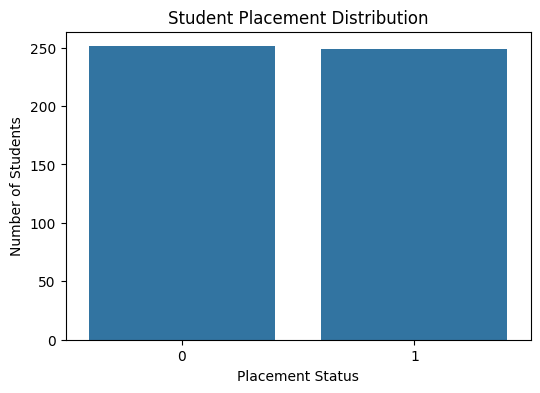

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Placed', data=df)

plt.title('Student Placement Distribution')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')
plt.show()

In [9]:
X = df.drop('Placed', axis=1)
y = df['Placed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 8)
Testing Data: (100, 8)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():

    if name in ['Logistic Regression', 'KNN']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(name, "Accuracy:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 100.0 %
Decision Tree Accuracy: 83.0 %
Random Forest Accuracy: 91.0 %
KNN Accuracy: 86.0 %


                 Model  Accuracy
0  Logistic Regression      1.00
1        Decision Tree      0.83
2        Random Forest      0.91
3                  KNN      0.86


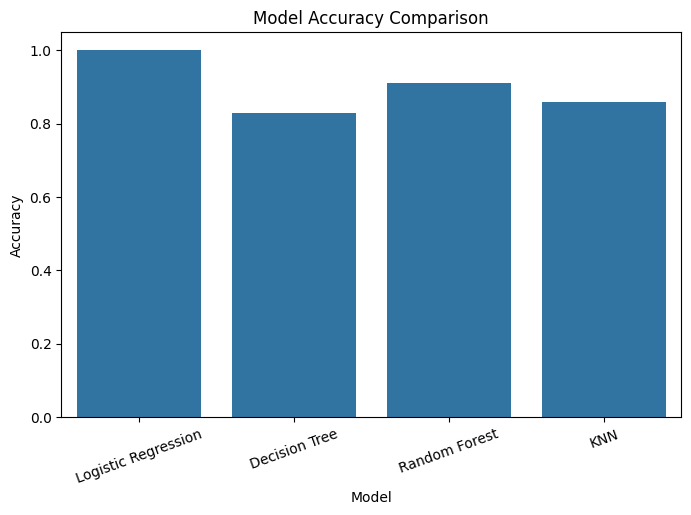

In [11]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
)

print(results_df)

plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=results_df)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 91.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        50
           1       0.94      0.88      0.91        50

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



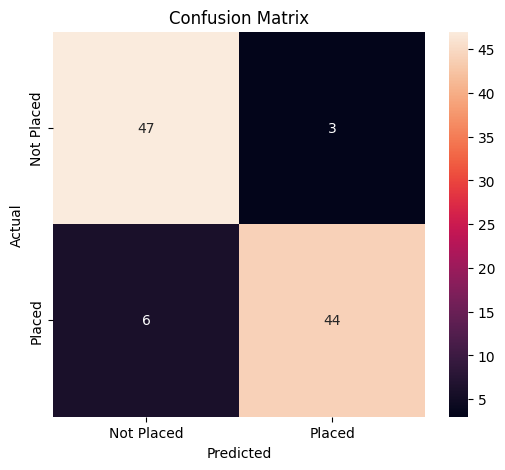

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Placed', 'Placed'],
    yticklabels=['Not Placed', 'Placed']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

               Feature  Importance
0                 CGPA    0.338330
7             Backlogs    0.188335
1       Aptitude_Score    0.097744
3  Communication_Score    0.097596
2      Technical_Score    0.097476
6           Attendance    0.067441
5          Internships    0.056723
4             Projects    0.056355


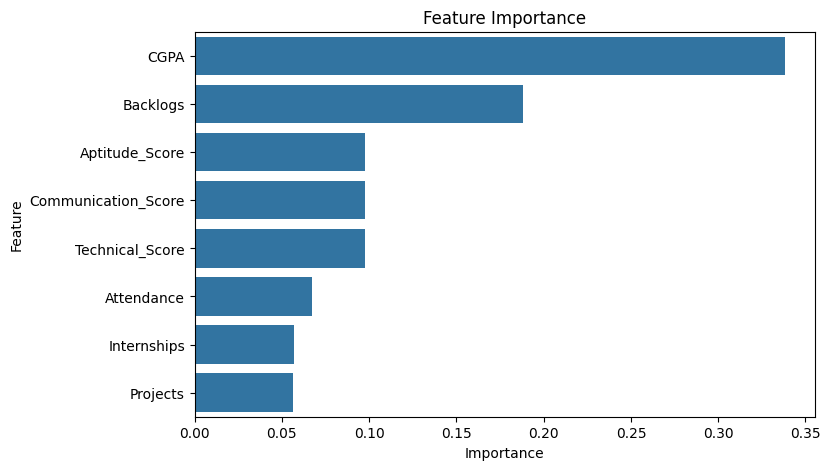

In [14]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

In [15]:
new_student = pd.DataFrame({
    'CGPA': [8.2],
    'Aptitude_Score': [85],
    'Technical_Score': [88],
    'Communication_Score': [82],
    'Projects': [3],
    'Internships': [2],
    'Attendance': [90],
    'Backlogs': [0]
})

prediction = rf_model.predict(new_student)
probability = rf_model.predict_proba(new_student)

if prediction[0] == 1:
    print("Prediction: STUDENT WILL BE PLACED")
else:
    print("Prediction: STUDENT WILL NOT BE PLACED")

print("Placement Probability:",
      round(probability[0][1] * 100, 2), "%")

Prediction: STUDENT WILL BE PLACED
Placement Probability: 99.0 %
